In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

sns.set()

Q1 : Create a multi-line plot of monthly sales trends for each
product Category over all years. Identify seasonal peaks and
consistent growth patterns.

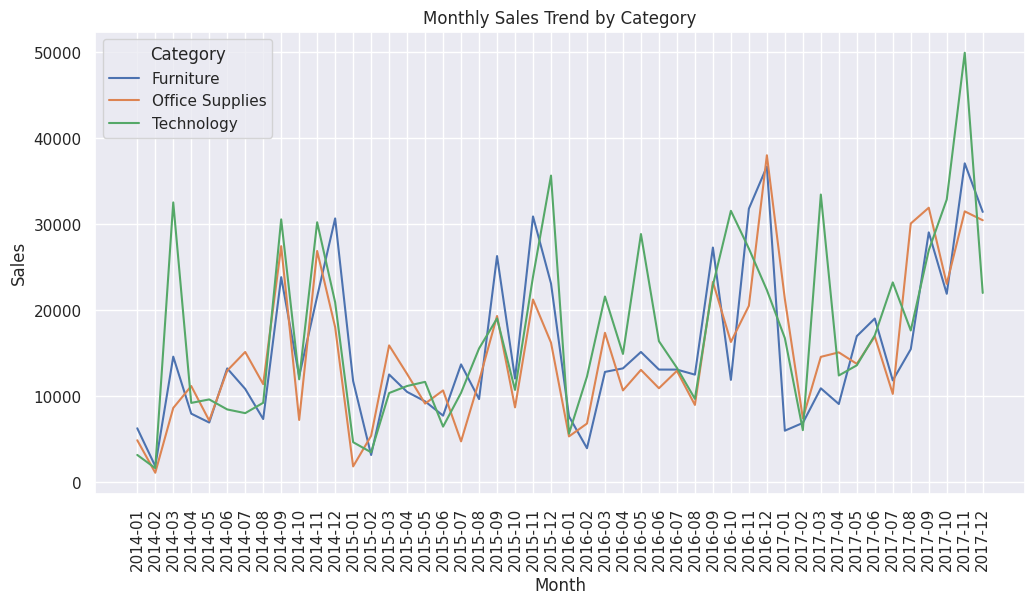

In [2]:
monthly_sales = df.groupby(['Month', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Category')
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend by Category")
plt.show()

Insight:

Sales peak in Nov–Dec (seasonal effect)
Technology shows steady growth over years

Q2. Generate a scatter plot of &#39;Discount&#39; vs. &#39;Profit&#39;. Color points
by Category. Add a horizontal reference line at Profit=0. Identify
the discount threshold causing losses.

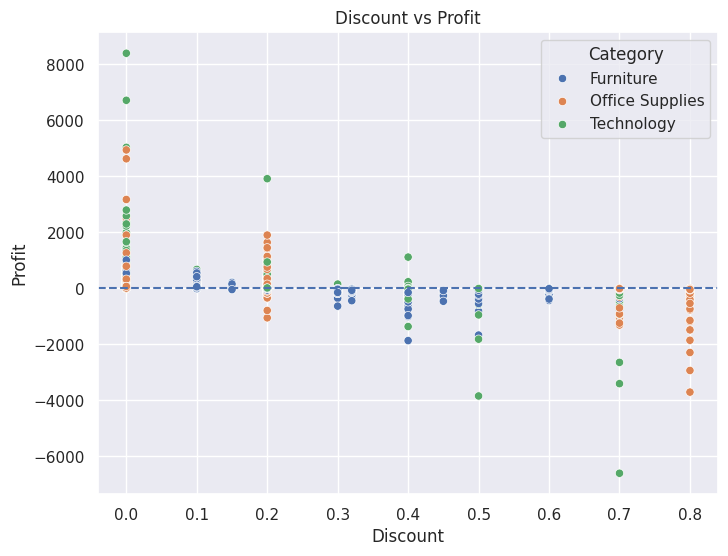

In [3]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.axhline(0, linestyle='--')
plt.title("Discount vs Profit")
plt.show()

Insight:


*   Losses start around 0.2–0.3 discount
* Furniture category often goes into loss

Q3. Visualize the distribution of Sales using a histogram with
adaptive binning. Overlay a KDE curve. Identify the typical order
value range.

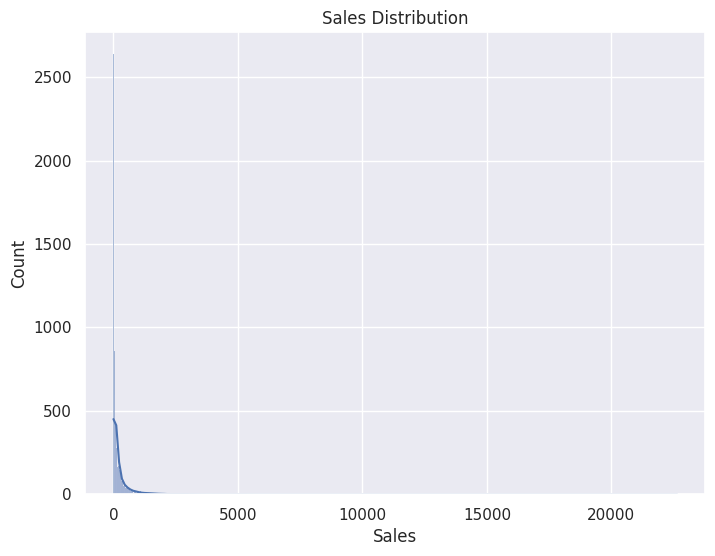

In [4]:
plt.figure(figsize=(8,6))
sns.histplot(df['Sales'], kde=True, bins='auto')
plt.title("Sales Distribution")
plt.show()

Insight:

Most orders fall in low sales range (100–500 approx)

Q4. Create a density plot (KDE) of Profit grouped by Region.
Identify which region shows consistent profitability and which is
most volatile.

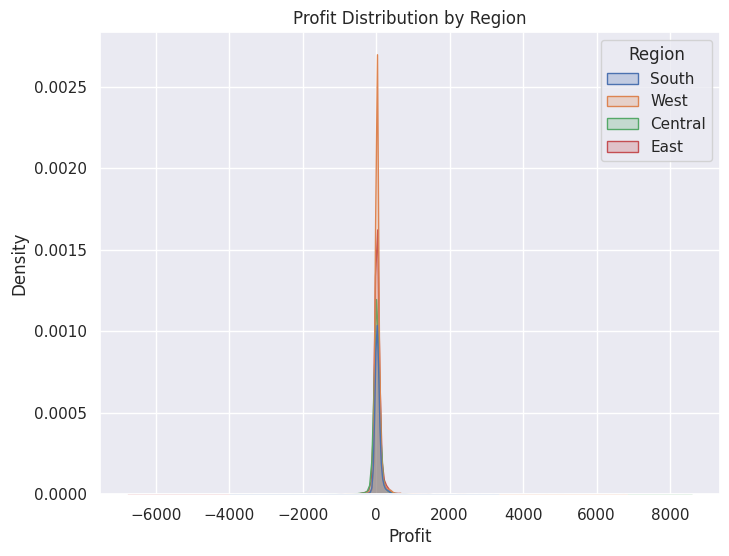

In [5]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df, x='Profit', hue='Region', fill=True)
plt.title("Profit Distribution by Region")
plt.show()

Insight:



*  West → stable profits
*   Central → high fluctuations (risky)

Q5. Use a 2D contour plot (sns.kdeplot) of &#39;Sales&#39; vs. &#39;Profit&#39; per
category using subplots. Compare joint distributions to identify
the healthiest category.

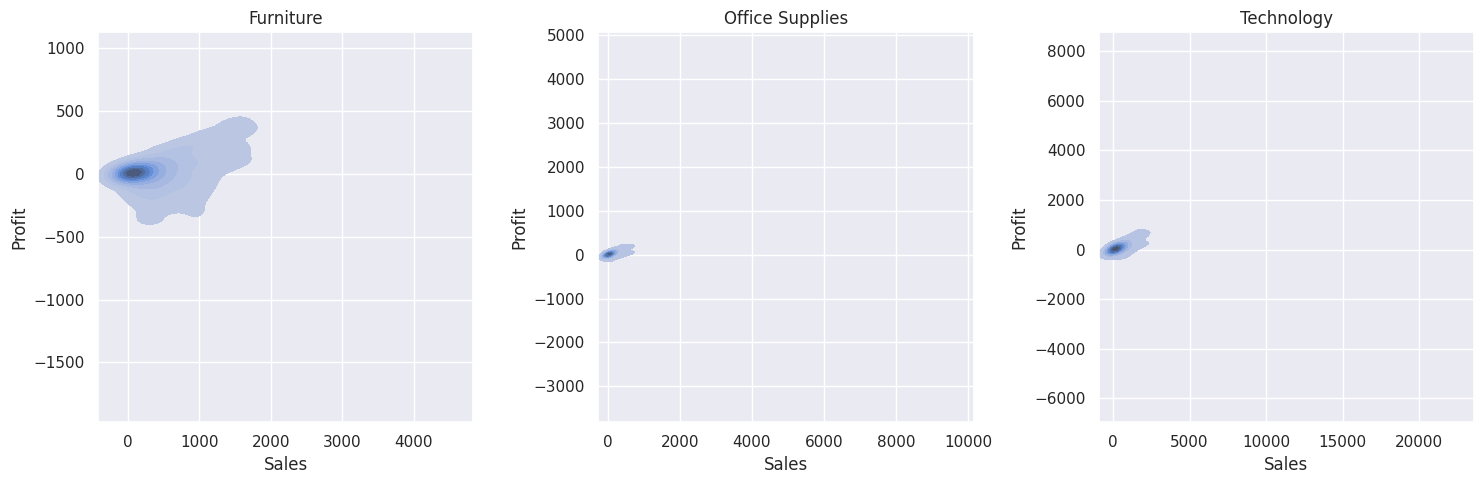

In [6]:
categories = df['Category'].unique()

fig, axes = plt.subplots(1, len(categories), figsize=(15,5))

for i, cat in enumerate(categories):
    subset = df[df['Category'] == cat]
    sns.kdeplot(data=subset, x='Sales', y='Profit', fill=True, ax=axes[i])
    axes[i].set_title(cat)

plt.tight_layout()
plt.show()

Insight:


*   Technology → best (high sales + profit)
*   Furniture → loss regions visible




Q6. Visualize error bars for average profit per Sub-Category
(mean ± std). Identify the sub-categories with the most volatile
and consistently profitable margins.

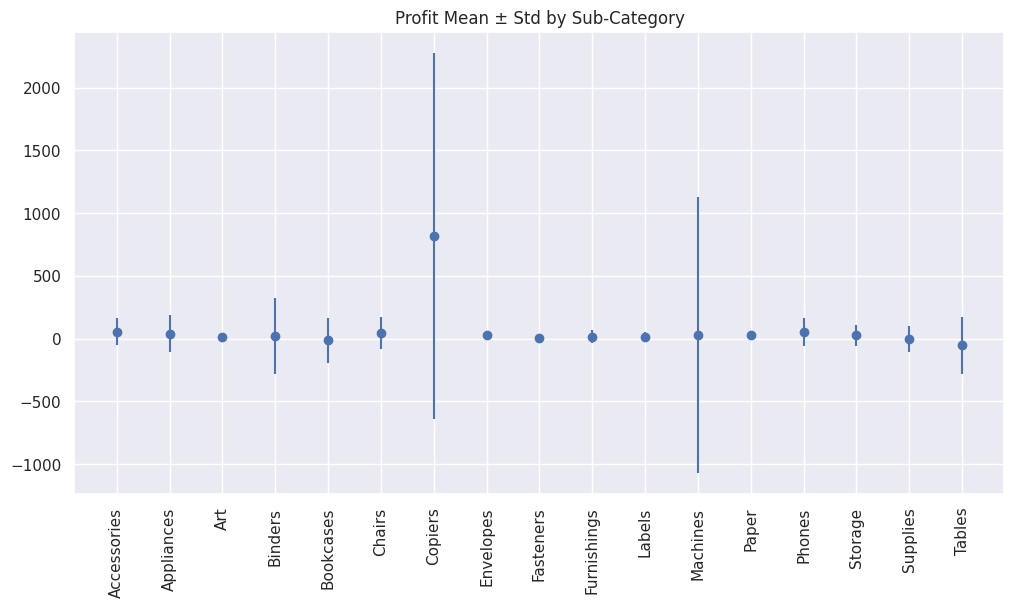

In [7]:
subcat = df.groupby('Sub-Category')['Profit'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(12,6))
plt.errorbar(subcat['Sub-Category'], subcat['mean'], yerr=subcat['std'], fmt='o')
plt.xticks(rotation=90)
plt.title("Profit Mean ± Std by Sub-Category")
plt.show()

Insight:

*   High volatility → Tables, Bookcases
*   Stable → Phones, Accessories

Q7. Build a 3x2 subplot grid: (a) bar chart of total sales by
region, (b) line plot of profit trend by year, (c) boxplot of discount
by category, (d) scatter of sales vs. quantity, (e) heatmap of
pivot table, (f) histogram of profit.

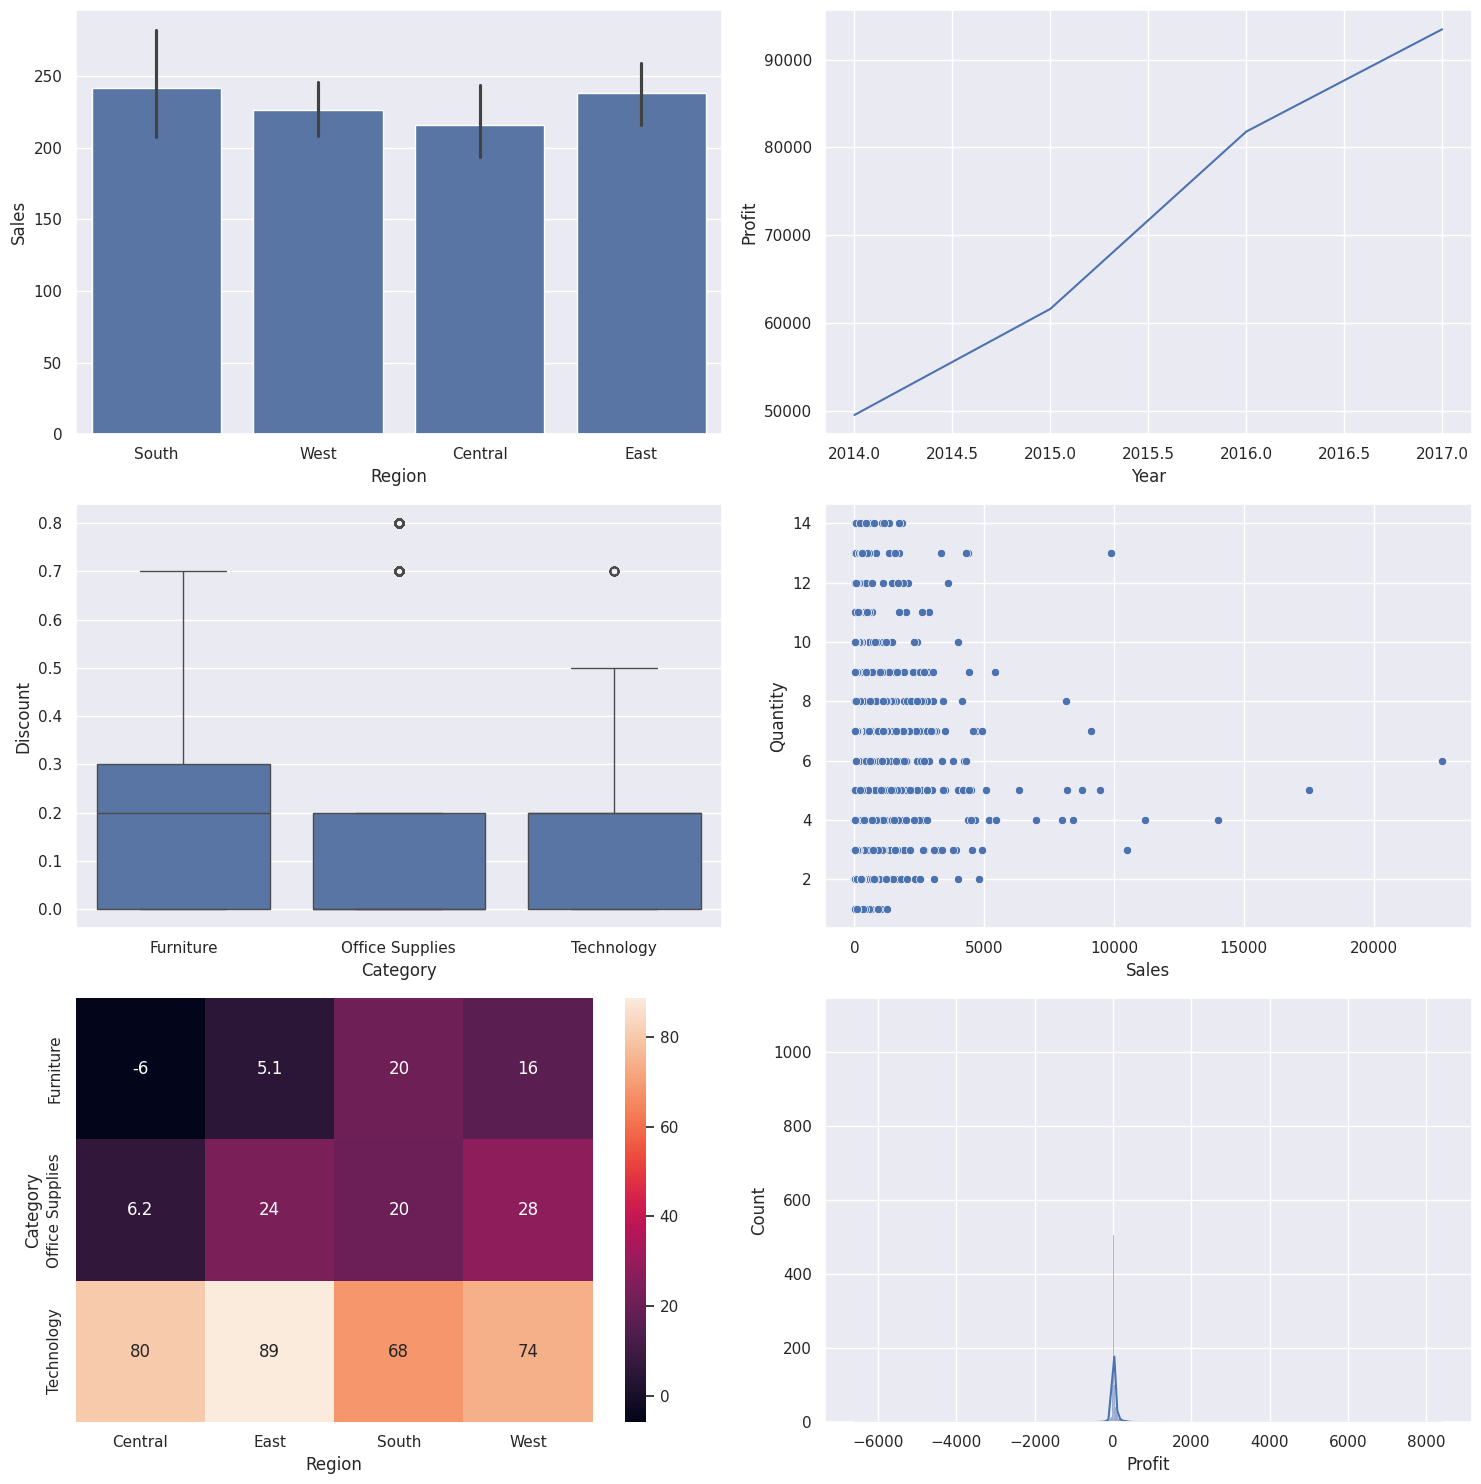

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(15,15))

sns.barplot(data=df, x='Region', y='Sales', ax=axes[0,0])

year_profit = df.groupby('Year')['Profit'].sum().reset_index()
sns.lineplot(data=year_profit, x='Year', y='Profit', ax=axes[0,1])

sns.boxplot(data=df, x='Category', y='Discount', ax=axes[1,0])

sns.scatterplot(data=df, x='Sales', y='Quantity', ax=axes[1,1])

pivot = df.pivot_table(values='Profit', index='Category', columns='Region')
sns.heatmap(pivot, annot=True, ax=axes[2,0])

sns.histplot(df['Profit'], kde=True, ax=axes[2,1])

plt.tight_layout()
plt.show()

Q8. Use Seaborn&#39;s lineplot with confidence intervals to show
yearly profit trend per segment (Consumer, Corporate, Home
Office). Identify the fastest-growing segment.

/tmp/ipykernel_3975/3612262487.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x='Year', y='Profit', hue='Segment', ci='sd')


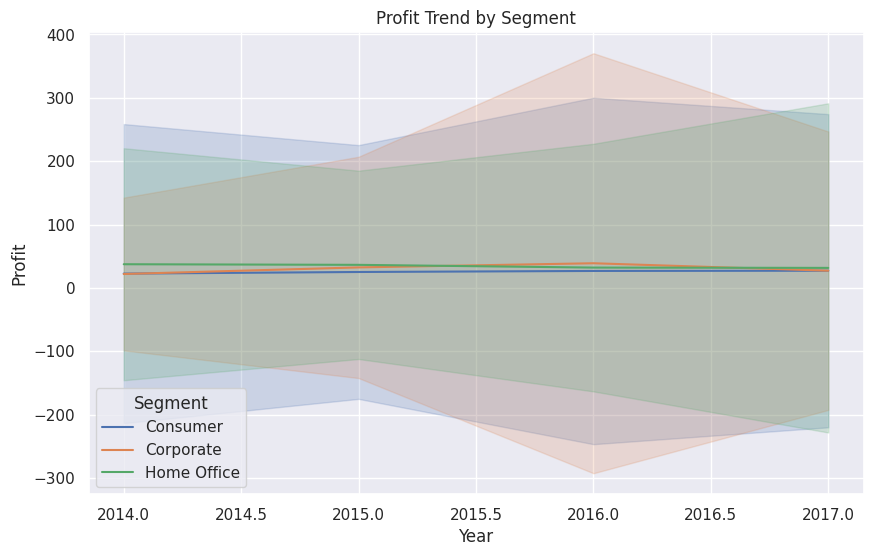

In [9]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='Profit', hue='Segment', ci='sd')
plt.title("Profit Trend by Segment")
plt.show()

Q9. Create a Seaborn heatmap of a pivot table showing
average profit by Sub-Category (rows) and Region (columns).
Annotate and identify regional sub-category champions.

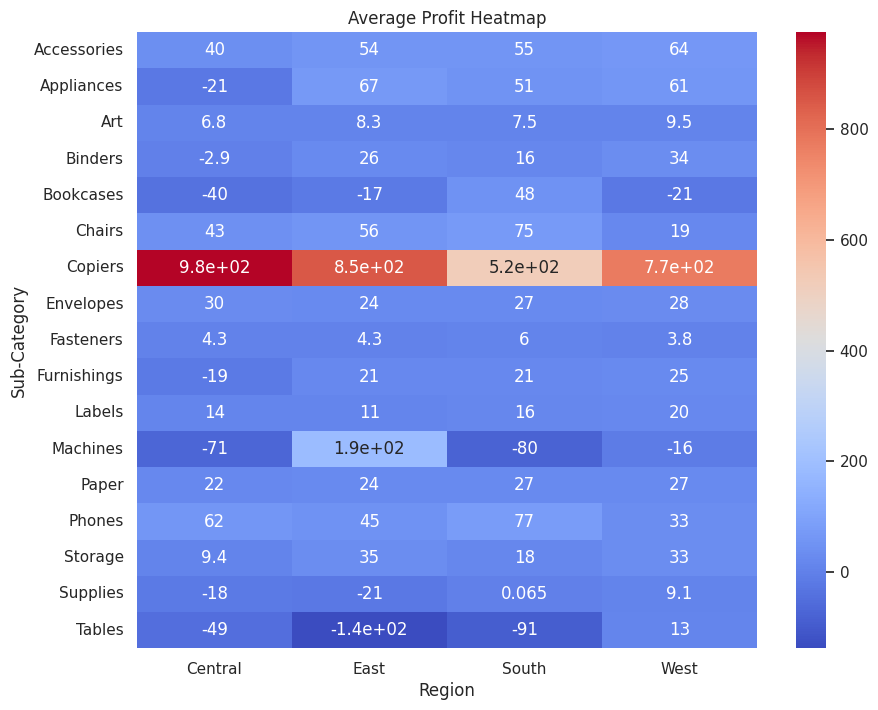

In [10]:
pivot = df.pivot_table(values='Profit',
                       index='Sub-Category',
                       columns='Region',
                       aggfunc='mean')

plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Average Profit Heatmap")
plt.show()

Insights :

*   Phones perform best
*   Tables show losses in many regions



Q10. Use Seaborn&#39;s FacetGrid to visualize profit distributions by
category across different shipping modes. Identify optimal
shipping strategy per category. Upload to GitHub.

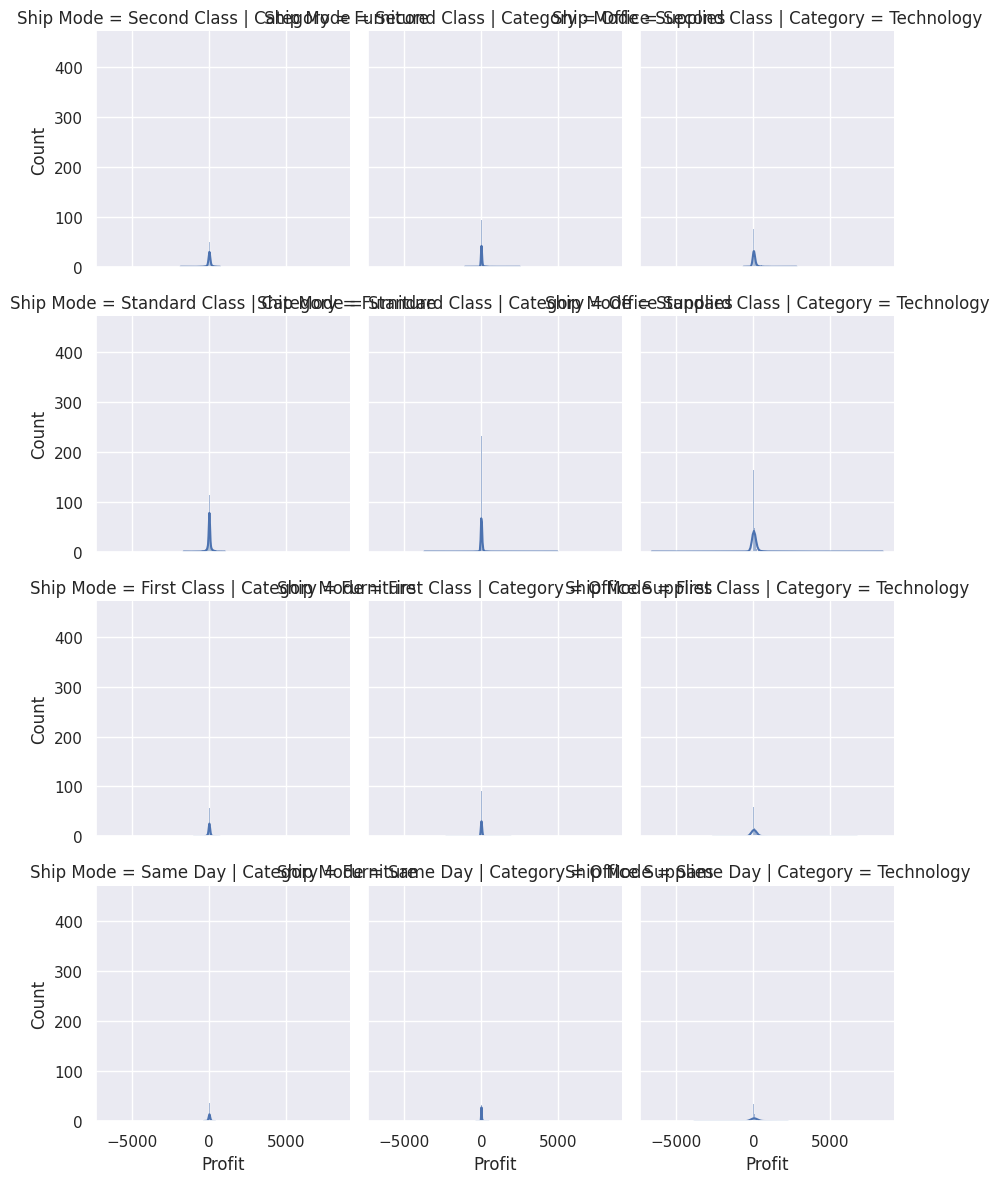

In [11]:
g = sns.FacetGrid(df, col="Category", row="Ship Mode", height=3)
g.map(sns.histplot, "Profit", kde=True)

plt.show()